## Explicação do dataset criado

## Parâmentros de variáveis

In [6]:
!pip install truncnorm

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.stats import truncnorm

# ========================
# PARÂMETROS DO DATASET
# ========================

PARAMS = {
    "n_alunos": 50000,  # número total de alunos
    "proporcao_evasao_geral": 0.10,  # taxa geral de evasão
    "evasao_por_etapa": {  # evasão específica por série
        "1° EF": 0.002, "2° EF": 0.001, "3° EF": 0.002, "4° EF": 0.002,
        "5° EF": 0.002, "6° EF": 0.01, "7° EF": 0.014, "8° EF": 0.012,
        "9° EF": 0.018, "1° EM": 0.04, "2° EM": 0.046, "3° EM": 0.03
    },

    # probabilidades base de cada variável para não evasão
    "p_estudante_nis": 0.3,
    "p_informou_nome_mae": 0.95,
    "p_informou_nome_pai": 0.7,
    "p_possui_deficiencia": 0.05,
    "p_repetente": 0.047,
    "p_trabalha": 0.15,
    "p_problemas_de_saude": 0.1,
    "p_gravidez_na_adolescencia": 0.03,
    "p_necessita_assistencia_social": 0.3,
    "raca_cor_p": [0.35, 0.1, 0.45, 0.05, 0.02, 0.03],
    "tipo_localizacao_p": [0.8, 0.2], 
    "situacao_consolidada_p": [0.7, 0.15, 0.1, 0.05],
    "infraestrutura_p": [0.5, 0.3, 0.2],
    "random_seed": 42
}

infraestrutura_vals = ['Boa', 'Regular', 'Ruim']

random.seed(PARAMS["random_seed"])
np.random.seed(PARAMS["random_seed"])

# ========================
# LISTAS DE CATEGORIAS
# ========================

etapas = ["1° EF", "2° EF", "3° EF", "4° EF", "5° EF", "6° EF",
          "7° EF", "8° EF", "9° EF", "1° EM", "2° EM", "3° EM"]

sexos = ['Masculino', 'Feminino', 'Outro']
raca_list = ['Branca', 'Preta', 'Parda', 'Amarela', 'Indígena', 'Não declarada']

# ========================
# FUNÇÕES AUXILIARES
# ========================

def escolher_por_prob(lista, probs):
    return np.random.choice(lista, p=probs)

def gerar_etapas(n):
    # distribui alunos conforme matrículas reais por etapa
    qtd_matriculas_etapas = np.array([28087, 29163, 33253, 28054, 28682, 29944,
                                      30364, 28886, 30368, 31195, 29372, 25056], dtype=float)
    distr = qtd_matriculas_etapas / qtd_matriculas_etapas.sum()
    return list(np.random.choice(etapas, size=n, p=distr))

def gerar_evasao_por_etapa(etapa):
    # retorna a taxa de evasão correspondente à etapa
    return PARAMS["evasao_por_etapa"].get(etapa, PARAMS["proporcao_evasao_geral"])

# ========================
# DISTRIBUIÇÃO NORMAL PARA VARIÁVEIS BOOLEANAS
# ========================

def gerar_variavel_normal(p_media, desvio=0.1):
    """Gera True/False seguindo probabilidade com leve variação normal."""
    p = truncnorm.rvs((0 - p_media) / desvio, (1 - p_media) / desvio, loc=p_media, scale=desvio)
    p = max(0, min(1, p))  # mantém p entre 0 e 1
    return random.random() < p

# ========================
# GERAÇÃO DE VARIÁVEIS
# ========================

idades = list(range(6, 20))
pesos_idades = np.linspace(1, 0.5, len(idades))  # idades mais novas têm mais peso
pesos_idades_evadiu = np.linspace(0.3, 1, len(idades))  # evadidos tendem a ser mais velhos

def gerar_idade(evadiu: bool):
    return random.choices(idades, weights=pesos_idades_evadiu if evadiu else pesos_idades)[0]

def gerar_sexo(evadiu: bool):
    return random.choices(sexos, weights=[0.48, 0.48, 0.04])[0]

# cada função abaixo altera levemente a probabilidade caso o aluno tenha evadido
def gerar_estudante_nis(evadiu: bool):
    p = 0.45 if evadiu else PARAMS["p_estudante_nis"]
    return gerar_variavel_normal(p)

def gerar_informou_nome_mae(evadiu: bool):
    p = 0.9 if evadiu else PARAMS["p_informou_nome_mae"]
    return gerar_variavel_normal(p)

def gerar_informou_nome_pai(evadiu: bool):
    p = 0.6 if evadiu else PARAMS["p_informou_nome_pai"]
    return gerar_variavel_normal(p)

def gerar_possui_deficiencia(evadiu: bool):
    p = 0.08 if evadiu else PARAMS["p_possui_deficiencia"]
    return gerar_variavel_normal(p)

def gerar_repetente(evadiu: bool):
    p = 0.2 if evadiu else PARAMS["p_repetente"]
    return gerar_variavel_normal(p)

def gerar_trabalha(evadiu: bool):
    p = 0.25 if evadiu else PARAMS["p_trabalha"]
    return gerar_variavel_normal(p)

def gerar_problemas_de_saude(evadiu: bool):
    p = 0.15 if evadiu else PARAMS["p_problemas_de_saude"]
    return gerar_variavel_normal(p)

def gerar_gravidez_na_adolescencia(evadiu: bool):
    p = 0.08 if evadiu else PARAMS["p_gravidez_na_adolescencia"]
    return gerar_variavel_normal(p)

def gerar_necessita_assistencia_social(evadiu: bool):
    p = 0.45 if evadiu else PARAMS["p_necessita_assistencia_social"]
    return gerar_variavel_normal(p)

def gerar_infraestrutura(evadiu: bool):
    # alunos evadidos tendem a estudar em escolas piores
    pesos_evadiu = [0.35, 0.4, 0.25]
    return random.choices(infraestrutura_vals, weights=pesos_evadiu if evadiu else PARAMS["infraestrutura_p"])[0]

def gerar_distancia(evadiu: bool):
    media = 3 if evadiu else 2  # evadidos moram mais longe
    return round(abs(np.random.normal(media, 1)), 1)

def gerar_renda(evadiu: bool):
    faixa = (0, 3) if evadiu else (1, 8)  # faixa de salários mínimos
    salario_min = 1139.4
    renda_sm = np.random.uniform(*faixa)
    return round(renda_sm * salario_min, 2)

def gerar_nivel_socioeconomico(evadiu: bool):
    niveis = ["Muito baixo", "Baixo", "Médio", "Alto", "Muito alto"]
    pesos_evadiu = [0.3, 0.4, 0.25, 0.04, 0.01]
    return random.choices(niveis, weights=pesos_evadiu if evadiu else [0.1, 0.3, 0.4, 0.15, 0.05])[0]

def gerar_raca(evadiu: bool):
    pesos_evadiu = [0.25, 0.15, 0.45, 0.03, 0.02, 0.1]
    return random.choices(raca_list, weights=pesos_evadiu if evadiu else PARAMS["raca_cor_p"])[0]

def gerar_tipo_localizacao(evadiu: bool):
    # mais evasão em áreas rurais
    return random.choices(['Urbana', 'Rural'], weights=[0.7, 0.3] if evadiu else PARAMS["tipo_localizacao_p"])[0]

def gerar_situacao_consolidada(evadiu: bool):
    if evadiu:
        return 'Evadido'
    return random.choices(['Aprovado', 'Reprovado', 'Evadido', 'Em andamento'], weights=PARAMS["situacao_consolidada_p"])[0]

def gerar_nota(evadiu: bool):
    # notas mais baixas entre evadidos
    dist = {(0, 5): 0.45, (5, 7): 0.40, (7, 10): 0.15} if evadiu else {(0, 5): 0.2, (5, 7): 0.35, (7, 10): 0.45}
    faixa = random.choices(list(dist.keys()), weights=list(dist.values()))[0]
    return round(np.random.uniform(*faixa), 1)

def gerar_frequencia(evadiu: bool):
    media = 75 if evadiu else 90  # frequência média menor para evadidos
    desvio = 10
    a, b = (0 - media) / desvio, (100 - media) / desvio
    return round(truncnorm.rvs(a, b, loc=media, scale=desvio), 1)

# ========================
# GERAÇÃO DO DATASET
# ========================

n_alunos = PARAMS["n_alunos"]
etapa_series = gerar_etapas(n_alunos)  # gera etapas conforme distribuição real
serie_evasao = [random.random() < gerar_evasao_por_etapa(etapa) for etapa in etapa_series]

# cria DataFrame inicial
df = pd.DataFrame({
    'id_aluno': np.arange(1, n_alunos + 1),
    'etapa_ensino': etapa_series,
    'evasao': serie_evasao,
})

# gera variáveis dependentes de evasão
df['idade'] = [gerar_idade(e) for e in df['evasao']]
df['sexo'] = [gerar_sexo(e) for e in df['evasao']]
df['estudante_nis'] = [gerar_estudante_nis(e) for e in df['evasao']]
df['informou_nome_mae'] = [gerar_informou_nome_mae(e) for e in df['evasao']]
df['informou_nome_pai'] = [gerar_informou_nome_pai(e) for e in df['evasao']]
df['possui_deficiencia'] = [gerar_possui_deficiencia(e) for e in df['evasao']]
df['raca_cor'] = [gerar_raca(e) for e in df['evasao']]
df['tipo_localizacao_endereco_estudante'] = [gerar_tipo_localizacao(e) for e in df['evasao']]
df['situacao_consolidada_no_ano'] = [gerar_situacao_consolidada(e) for e in df['evasao']]
df['repetente'] = [gerar_repetente(e) for e in df['evasao']]
df['frequencia_escolar'] = [gerar_frequencia(e) for e in df['evasao']]
df['notas_medias'] = [gerar_nota(e) for e in df['evasao']]
df['nivel_socioeconomico'] = [gerar_nivel_socioeconomico(e) for e in df['evasao']]
df['renda_familiar'] = [gerar_renda(e) for e in df['evasao']]
df['distancia_da_escola_km'] = [gerar_distancia(e) for e in df['evasao']]
df['trabalha'] = [gerar_trabalha(e) for e in df['evasao']]
df['problemas_de_saude'] = [gerar_problemas_de_saude(e) for e in df['evasao']]
df['gravidez_na_adolescencia'] = [gerar_gravidez_na_adolescencia(e) for e in df['evasao']]
df['necessita_assistencia_social'] = [gerar_necessita_assistencia_social(e) for e in df['evasao']]
df['infraestrutura_escolar'] = [gerar_infraestrutura(e) for e in df['evasao']]

df['pontuacao_risco'] = (
     (100 - df['frequencia_escolar']) / 100 * 0.3 +
     (10 - df['notas_medias']) / 10 * 0.3
)

df['pontuacao_risco'] = df['pontuacao_risco'] / df['pontuacao_risco'].max()

df['evasao_confirmada'] = [np.random.rand() < r for r in df['pontuacao_risco']]

# ========================
# SALVA RESULTADO
# ========================

csv_path = "./dataset_evasao_sintetico_v4.csv"
df.to_csv(csv_path, index=False)

print(df.head())


✅ Dataset gerado com sucesso e salvo em: ./dataset_evasao_sintetico_v4.csv
   id_aluno etapa_ensino  evasao  idade       sexo  estudante_nis  \
0         1        5° EF   False     19   Feminino           True   
1         2        3° EM    True     16   Feminino           True   
2         3        9° EF   False      7   Feminino          False   
3         4        8° EF   False     14   Feminino           True   
4         5        2° EF   False      8  Masculino          False   

   informou_nome_mae  informou_nome_pai  possui_deficiencia raca_cor  ...  \
0               True               True               False   Branca  ...   
1               True               True               False   Branca  ...   
2               True               True               False   Branca  ...   
3               True               True               False   Branca  ...   
4               True               True               False    Parda  ...   

  nivel_socioeconomico renda_familiar  distanci

## Funções de geração de variáveis

## Análise Exploratória

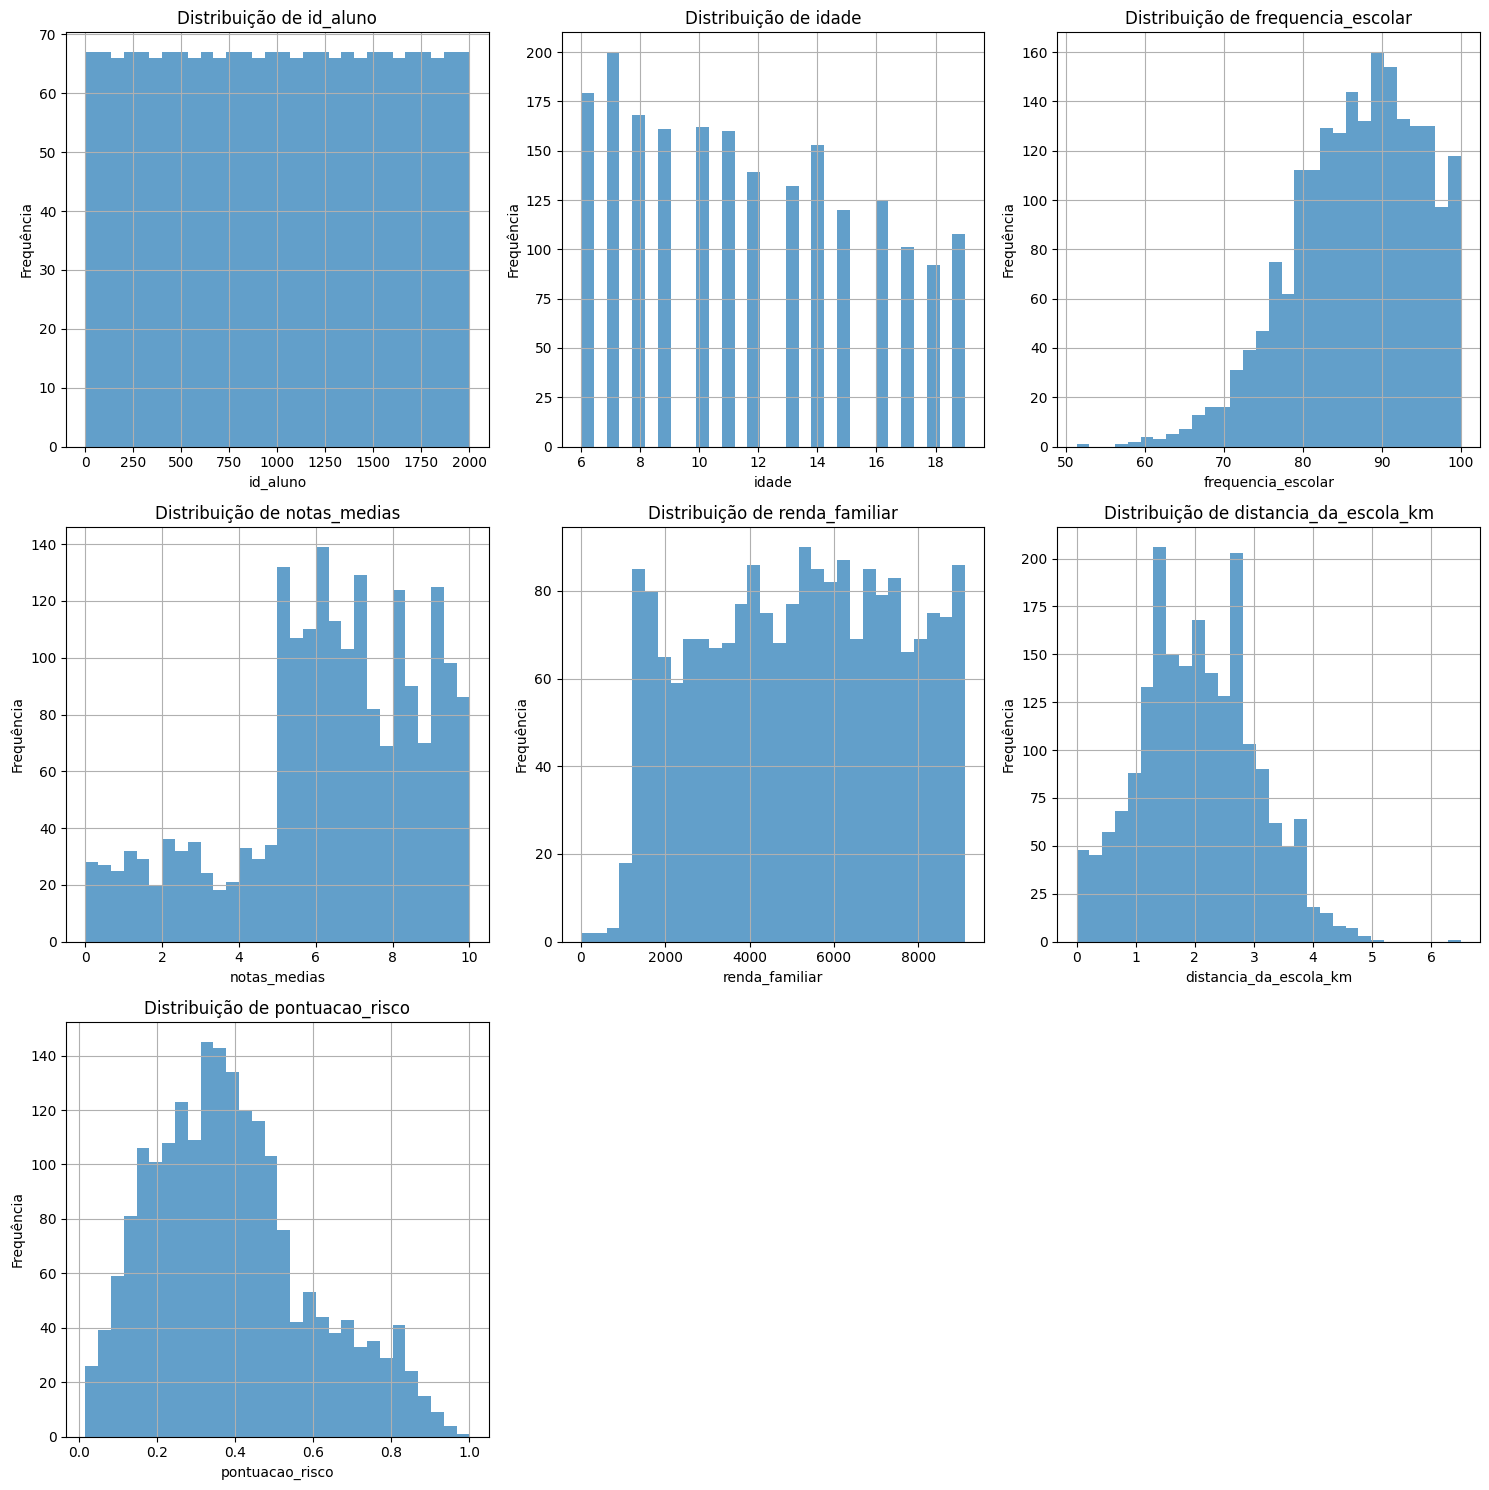

========== Var. Categóricas ==========


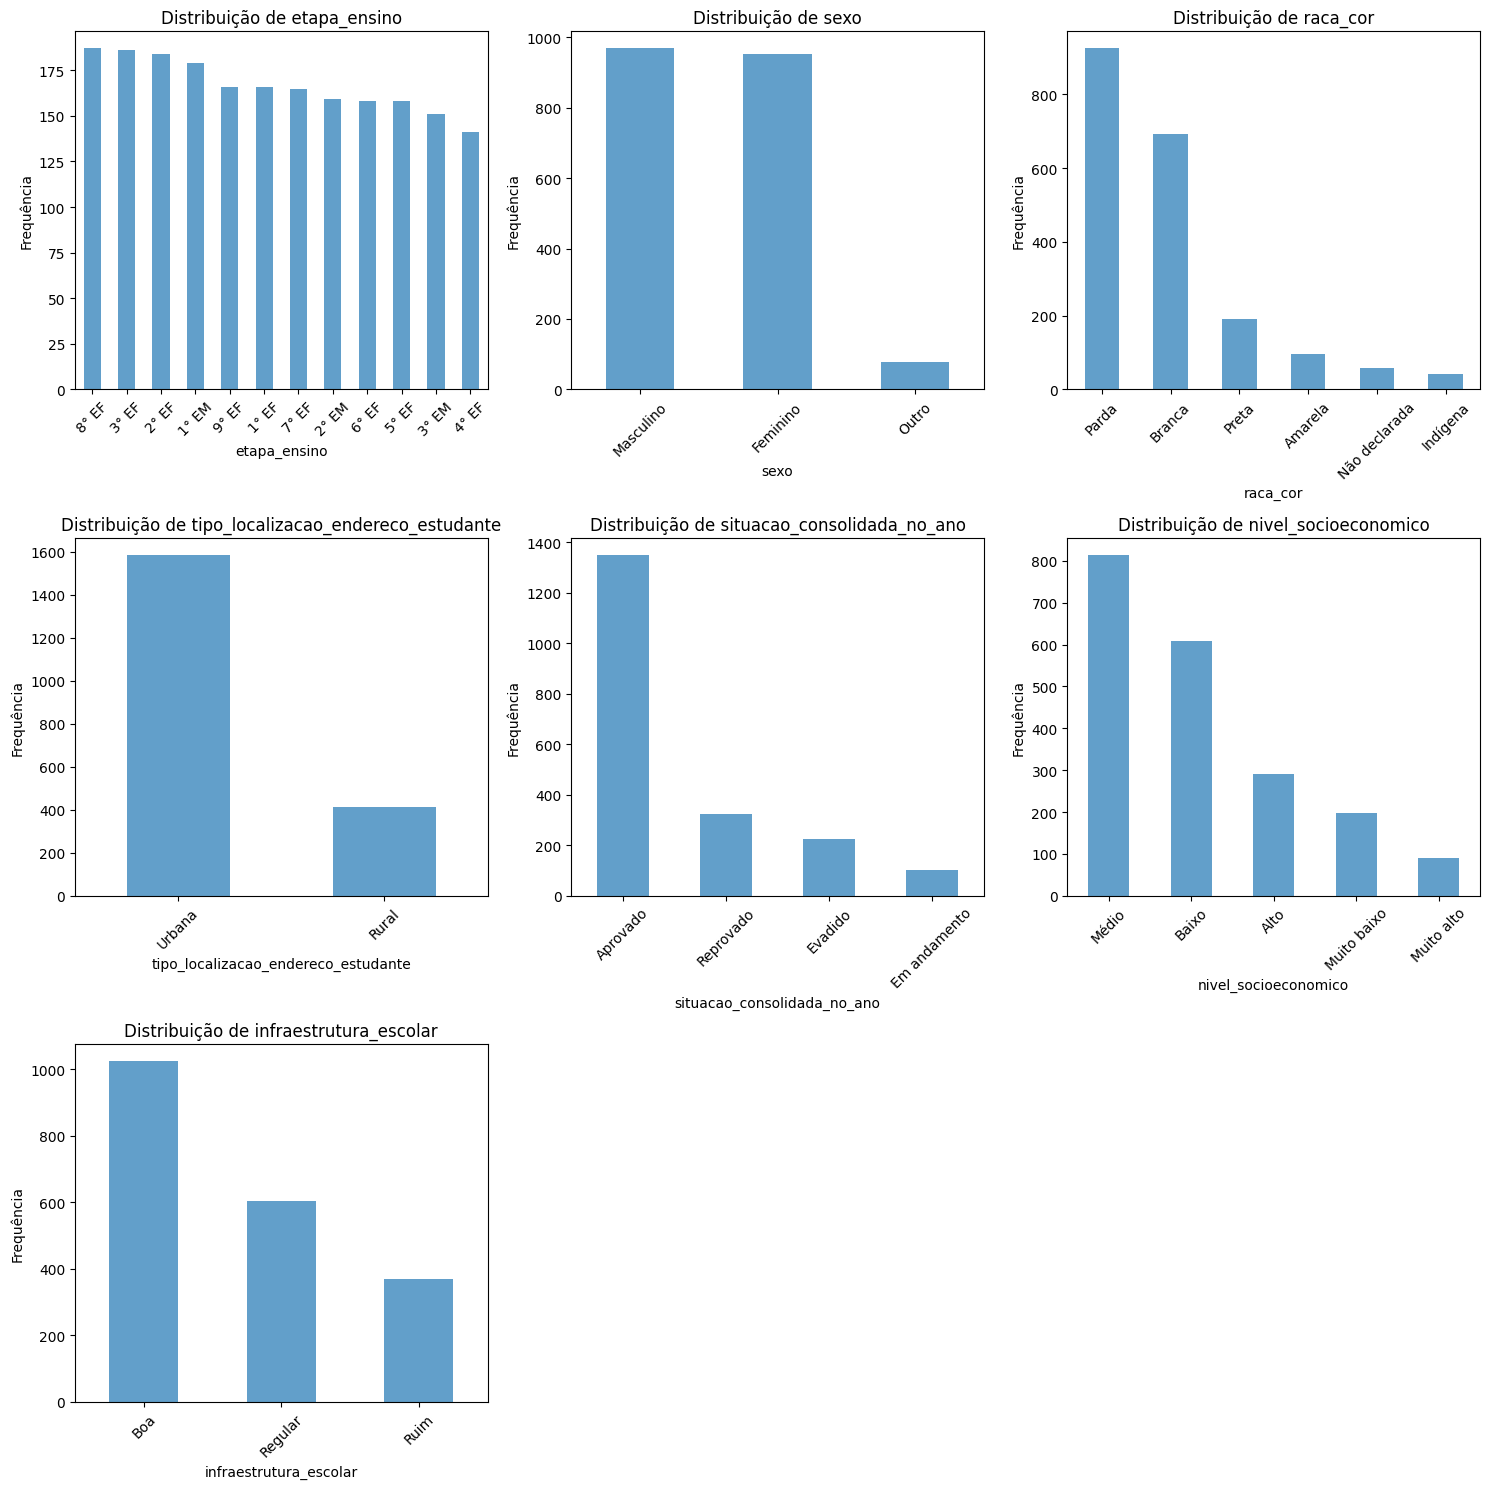

In [2]:
def plot_numerical_distributions(df):
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = len(numerical_cols)
    n_rows = (n_cols + 2) // 3  # 3 colunas por linha
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for i, col in enumerate(numerical_cols):
        df[col].hist(bins=30, ax=axes[i], alpha=0.7)
        axes[i].set_title(f'Distribuição de {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequência')
    
    # Remover subplots vazios
    for i in range(len(numerical_cols), len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.show()

# Para variáveis categóricas (gráficos de barras)
def plot_categorical_distributions(df):
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    n_cols = len(categorical_cols)
    n_rows = (n_cols + 2) // 3
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for i, col in enumerate(categorical_cols):
        df[col].value_counts().plot(kind='bar', ax=axes[i], alpha=0.7)
        axes[i].set_title(f'Distribuição de {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequência')
        axes[i].tick_params(axis='x', rotation=45)
    
    for i in range(len(categorical_cols), len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.show()

# Uso
plot_numerical_distributions(df)
print("="*10 + " Var. Categóricas " + "="*10)
plot_categorical_distributions(df)

## Heat Map

In [4]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


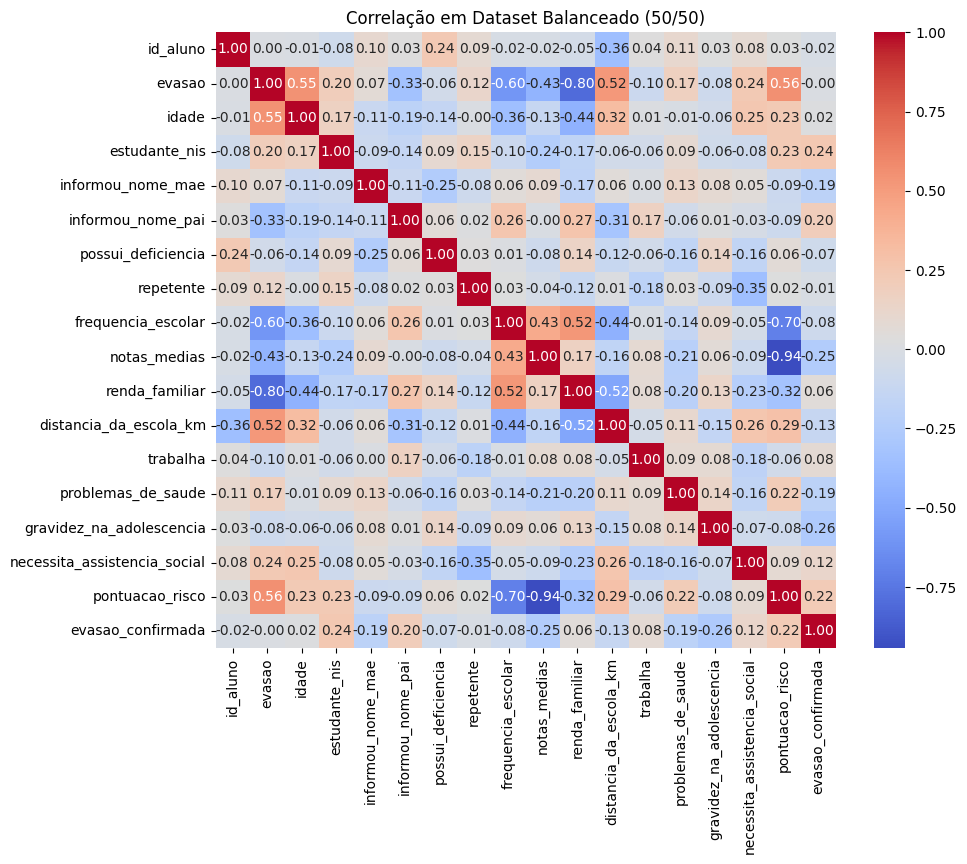

In [6]:
# --- TÉCNICA DE VALIDAÇÃO ---

# Separa os grupos
df_evadidos = df[df['evasao'] == 1]
df_nao_evadidos = df[df['evasao'] == 0]

# Pega a mesma quantidade de não evadidos (ex: se tem 300 evadidos, pega 300 não evadidos)
df_nao_evadidos_sample = df_nao_evadidos.sample(n=len(df_evadidos), random_state=42)

# Cria um dataset equilibrado APENAS para visualização
df_visualizacao = pd.concat([df_evadidos, df_nao_evadidos_sample])

# Agora plote o heatmap deste df_visualizacao
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(df_visualizacao.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlação em Dataset Balanceado (50/50)")
plt.show()